# Sensitivities

In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import simpson

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [3]:
def wavelength_to_color(wavelength: float):
    gamma = 0.8

    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        r = ((-(wavelength - 440) / (440 - 380)) * attenuation)**gamma
        g = 0.0
        b = (1.0 * attenuation)**gamma
    elif 440 < wavelength <= 490:
        r = 0.0
        g = ((wavelength - 440) / (490 - 440))**gamma
        b = 1.0**gamma
    elif 490 < wavelength <= 510:
        r = 0.0
        g = 1.0**gamma
        b = (-(wavelength - 510) / (510 - 490))**gamma
    elif 510 < wavelength <= 580:
        r = ((wavelength - 510) / (580 - 510))**gamma
        g = 1.0**gamma
        b = 0.0
    elif 580 < wavelength <= 645:
        r = 1.0**gamma
        g = (-(wavelength - 645) / (645 - 580))**gamma
        b = 0.0
    elif 645 < wavelength <= 780:
        attenuation = 0.3 + 0.7 * (780 - wavelength) / (780 - 645)
        r = (1.0 * attenuation)**gamma
        g = 0.0
        b = 0.0
    else:
        r = g = b = 0.0

    return r, g, b

## Sony IMX219

In [4]:
df = pd.read_csv('resources/sensitivities/Sony_IMX219.csv')

imx_w = df['Wavelength'].values
imx_mask = (imx_w >= 380) & (imx_w <= 700)

imx_w = imx_w[imx_mask]
imx_r = df['R'].values[imx_mask]
imx_g = df['G'].values[imx_mask]
imx_b = df['B'].values[imx_mask]

imx_r_scaled = imx_r / simpson(imx_r, imx_w)
imx_g_scaled = imx_g / simpson(imx_g, imx_w)
imx_b_scaled = imx_b / simpson(imx_b, imx_w)

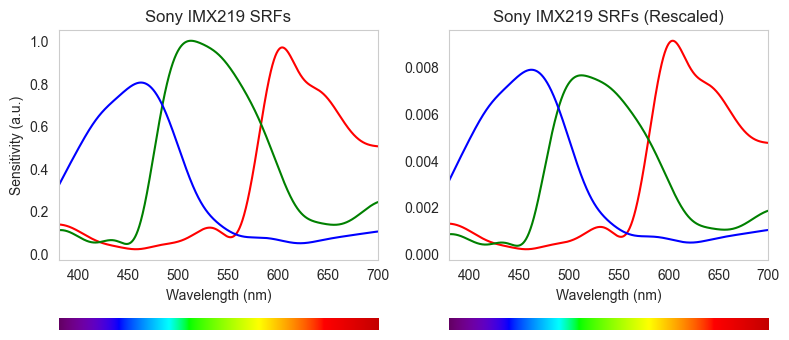

In [5]:
_, axes = plt.subplots(2, 2, figsize=(8, 3.5), gridspec_kw={'height_ratios': [19, 1]})

axes[0, 0].plot(imx_w, imx_r, color='r')
axes[0, 0].plot(imx_w, imx_g, color='g')
axes[0, 0].plot(imx_w, imx_b, color='b')
axes[0, 0].set_ylabel('Sensitivity (a.u.)')
axes[0, 0].set_title('Sony IMX219 SRFs')
axes[0, 0].set_xlabel('Wavelength (nm)')
axes[0, 0].set_xlim(380, 700)
axes[0, 0].grid(None)

axes[0, 1].plot(imx_w, imx_r_scaled, color='r')
axes[0, 1].plot(imx_w, imx_g_scaled, color='g')
axes[0, 1].plot(imx_w, imx_b_scaled, color='b')
axes[0, 1].set_title('Sony IMX219 SRFs (Rescaled)')
axes[0, 1].set_xlabel('Wavelength (nm)')
axes[0, 1].set_xlim(380, 700)
axes[0, 1].grid(None)

color_spectrum = np.array([wavelength_to_color(wl) for wl in imx_w])[None, :, :]
axes[1, 0].imshow(color_spectrum, extent=[380, 700, 0, 1], aspect='auto')
axes[1, 1].imshow(color_spectrum, extent=[380, 700, 0, 1], aspect='auto')
axes[1, 0].axis('off')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## CIE CMF

In [6]:
df = pd.read_csv('resources/sensitivities/CIE_xyz_1931.csv')

cmf_w = df['Wavelength'].values
cmf_mask = (cmf_w >= 380) & (cmf_w <= 700)

cmf_w = cmf_w[cmf_mask]
cmf_x = df['X'].values[cmf_mask]
cmf_y = df['Y'].values[cmf_mask]
cmf_z = df['Z'].values[cmf_mask]

In [7]:
M_xyz_to_rgb = np.array([
    [ 2.3706743, -0.9000405, -0.4706338],
    [-0.5138850,  1.4253036,  0.0885814],
    [ 0.0052982, -0.0146949,  1.0093968]
])

In [8]:
xyz_cmf = np.stack([cmf_x, cmf_y, cmf_z], axis=-1)
rgb_cmf = xyz_cmf @ M_xyz_to_rgb.T

In [9]:
cmf_r = rgb_cmf[:, 0]
cmf_g = rgb_cmf[:, 1]
cmf_b = rgb_cmf[:, 2]

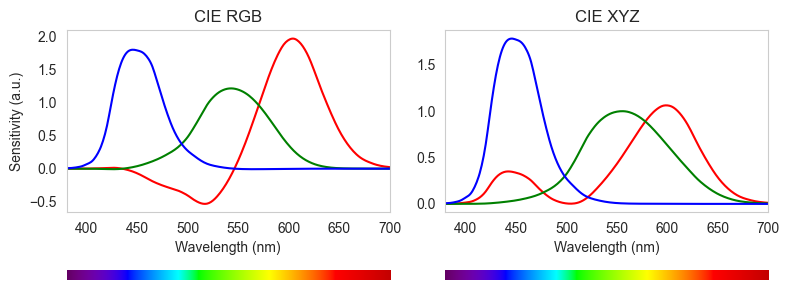

In [10]:
_, axes = plt.subplots(2, 2, figsize=(8, 3), gridspec_kw={'height_ratios': [19, 1]})

axes[0, 0].plot(cmf_w, cmf_r, color='r')
axes[0, 0].plot(cmf_w, cmf_g, color='g')
axes[0, 0].plot(cmf_w, cmf_b, color='b')
axes[0, 0].set_xlabel('Wavelength (nm)')
axes[0, 0].set_ylabel('Sensitivity (a.u.)')
axes[0, 0].set_title('CIE RGB')
axes[0, 0].set_xlim(380, 700)
axes[0, 0].grid(None)

axes[0, 1].plot(cmf_w, cmf_x, color='r')
axes[0, 1].plot(cmf_w, cmf_y, color='g')
axes[0, 1].plot(cmf_w, cmf_z, color='b')
axes[0, 1].set_xlabel('Wavelength (nm)')
axes[0, 1].set_title('CIE XYZ')
axes[0, 1].set_xlim(380, 700)
axes[0, 1].grid(None)

color_spectrum = np.array([wavelength_to_color(wl) for wl in imx_w])[None, :, :]
axes[1, 0].imshow(color_spectrum, extent=[380, 700, 0, 1], aspect='auto')
axes[1, 1].imshow(color_spectrum, extent=[380, 700, 0, 1], aspect='auto')
axes[1, 0].axis('off')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()